## Week 2 Assignment - End-to-end ML pipeline
Name : Sakshi Kiran Kekan 
College : Sanjivani College of Engineering, Kopargaon 
Domain : Data Science 

Objective:
- Perform EDA
- Create features
- Train Linear Regression and Random Forest models
- Evaluate performance
- Perform Time Series Analysis
- Generate Forecast Table

In [1]:
!pip install statsmodels

In [2]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import(
    KFold,
    cross_val_score,
    GridSearchCV
)
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

## Step 1 : Load Dataset and Basic Information

In [3]:
!pip install kagglehub

In [4]:
import kagglehub
import os
import pandas as pd

# Download dataset
path = kagglehub.dataset_download(
    "nalisha/tesla-ea-deliveries-and-production-data20152025"
)

print("Dataset path:")
print(path)

# See files
print("\nFiles:")
print(os.listdir(path))

# Load CSV
csv_file = os.path.join(
    path,
    "tesla_deliveries_dataset_2015_2025.csv"
)

df = pd.read_csv(csv_file)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nDescribe:")
display(df.describe())

Dataset path:
C:\Users\saksh\.cache\kagglehub\datasets\nalisha\tesla-ea-deliveries-and-production-data20152025\versions\1

Files:
['tesla_deliveries_dataset_2015_2025.csv']

Shape:
(2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   fl

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Dataset Information

The dataset contains Tesla delivery-related information from 2015 to 2025. It consists of 12 columns representing production, deliveries, regions, vehicle models, source types, and other business-related variables.

Basic dataset inspection was performed using:
- Shape of dataset
- Column names
- Data types and memory usage
- Statistical summary of numerical columns

These steps help in understanding the structure and quality of the data before analysis.

## Step 2: Identify Missing Values and Duplicate Records

In [5]:
print("Missing Values:")
display(df.isnull().sum())
print()
print("\nDuplicate values")
print(df.duplicated().sum())

Missing Values:


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64



Duplicate values
0


## Missing Values and Duplicate Records

Missing value analysis was performed to identify incomplete observations that could affect model performance. Duplicate row detection was also conducted to ensure data integrity.

Results showed the number of missing values and duplicate records present in the dataset. Cleaning data before model building improves accuracy and reliability of predictions.

## Step 3 : Exploratory Data Analysis (EDA)

### Deliveries by Model

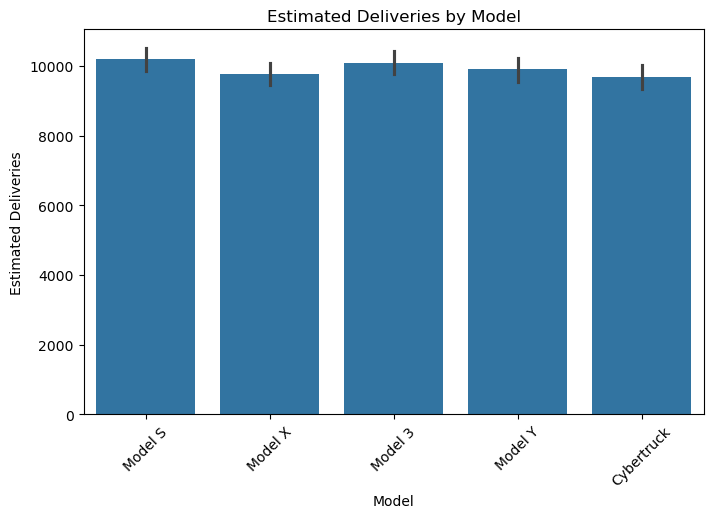

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=df["Model"],
    y=df["Estimated_Deliveries"]
)

plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation = 45)
plt.show()

Interpretation: Model Y has the highest estimated deliveries, indicating strong market demand. Other models contribute less compared to Model Y.

### Deliveries by Region

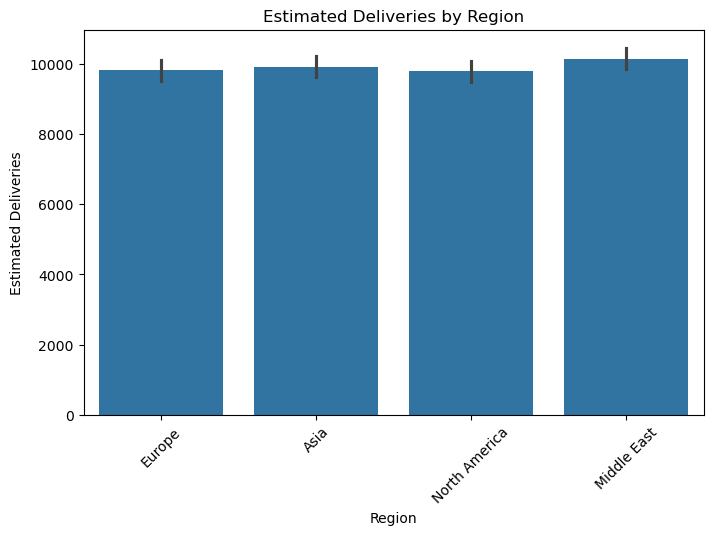

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    x = df["Region"],
    y = df["Estimated_Deliveries"]
)

plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation = 45)
plt.show()

Interpretation

Delivery distribution varies across regions. North America contributes the largest share of Tesla deliveries.

### Correlation Heatmap

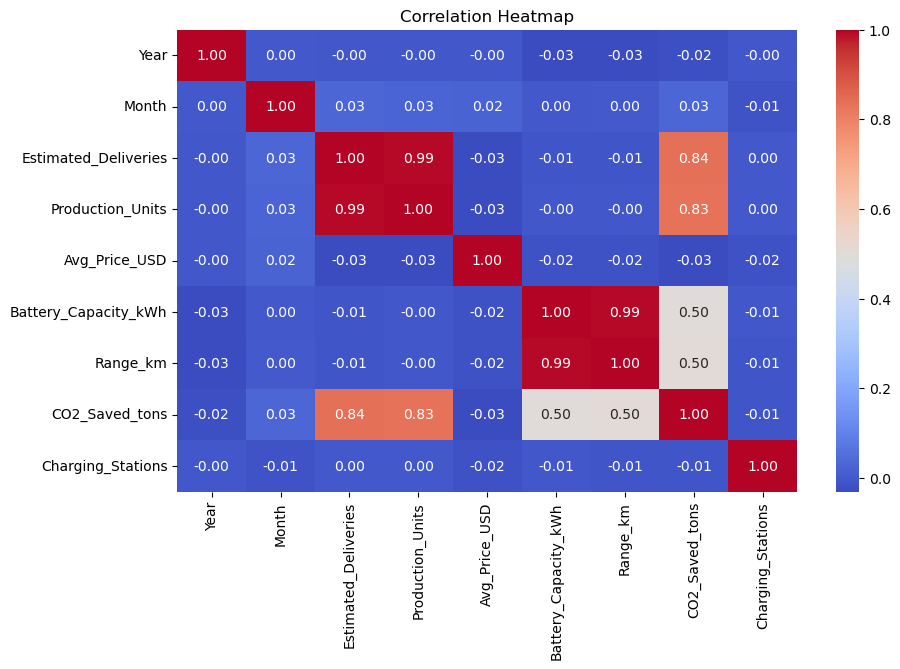

In [8]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include = np.number)
sns.heatmap(
    numeric_df.corr(),
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f"
)
plt.title("Correlation Heatmap")
plt.show()

Interpretation

Strong positive correlation exists between Production and Estimated Deliveries. This indicates that production volume directly influences deliveries.

### Production vs Deliveries Scatter Plot

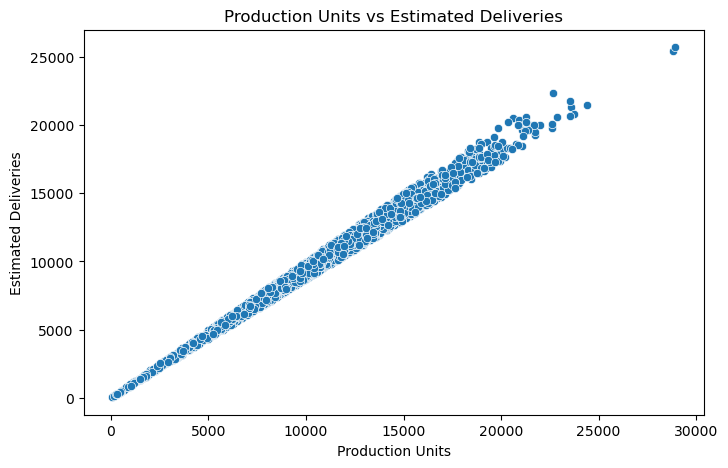

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x = df["Production_Units"],
    y = df["Estimated_Deliveries"]
)
plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.show()

Interpretation

The scatter plot shows a positive linear relationship between production and deliveries.

### Time Trend Line

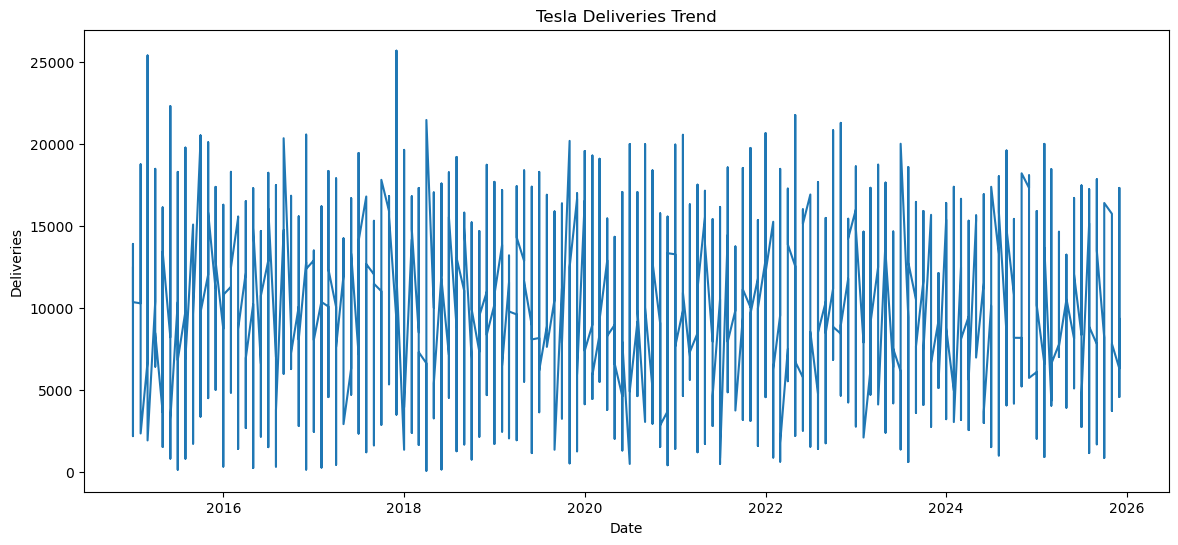

In [10]:
df["Date"]=pd.to_datetime(
    df["Year"].astype(str)
    +
    "-"
    +
    df["Month"].astype(str)
)

df=df.sort_values("Date")

plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Estimated_Deliveries"]
)

plt.title(
    "Tesla Deliveries Trend"
)

plt.xlabel("Date")
plt.ylabel(
    "Deliveries"
)

plt.show()

Interpretation

Tesla deliveries have generally increased over time, indicating continuous growth in production and market demand.

## Exploratory Data Analysis (EDA)

Five visualizations were created to understand patterns within the dataset:

1. Deliveries by Model
   - Shows which Tesla models contribute the most deliveries.

2. Deliveries by Region
   - Helps identify regional demand variations.

3. Correlation Heatmap
   - Displays relationships among numerical variables.
   - Strong positive correlation between Production_Units and Estimated_Deliveries is expected.

4. Production vs Deliveries Scatter Plot
   - Visualizes the relationship between production volume and deliveries.

5. Time Trend Line
   - Shows how Tesla deliveries changed over time.

EDA helps identify trends, relationships, and potential predictive variables.

## Step 4: Feature Engineering

In [11]:
label_encoders = {}
for col in ["Region","Model","Source_Type"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# lag Feature
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)

# Rolling Mean Feature
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

# Fill NaN
df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean(),
    inplace = True
)

df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean(),
    inplace = True
)

print(df[["Deliveries_Lag1","Rolling_Mean_3"]].isnull().sum())

Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


Observation

Lag features capture previous delivery trends, while rolling averages smooth short-term fluctuations and improve model performance.

## Feature Engineering

Feature engineering was performed to improve predictive performance.

The following transformations were applied:

1. Label Encoding
   - Region
   - Model
   - Source_Type

Categorical variables were converted into numerical values so machine learning algorithms could process them.

2. Deliveries_Lag1
   - Previous period deliveries.
   - Captures historical dependency.

3. Rolling_Mean_3
   - Three-period moving average of deliveries.
   - Helps smooth fluctuations and capture trends.

Missing values created by lagging and rolling operations were replaced with the mean values to ensure no null values remained.

In [12]:
X = df.drop(columns=["Estimated_Deliveries", "Date"])
y = df["Estimated_Deliveries"]

## Step 5: Train-Test Split (80 - 20)

In [13]:
target = "Estimated_Deliveries"

features = [col for col in df.columns
            if col not in ["Estimated_Deliveries", "Date"]]

X = df[features]
y = df[target]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (2112, 13)
Test Shape: (528, 13)


## Chronological Data Splitting

A chronological split was used instead of train_test_split.

Reason:
- Time-series data must preserve temporal order.
- Future observations should never be used to predict past observations.

The first 80% of records were used for training and the remaining 20% were used for testing. This approach better simulates real-world forecasting scenarios.

## Step 6: Linear Regression Model

In [14]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE : ",lr_mae)
print("RMSE : ",lr_rmse)
print("R2 : ", lr_r2)

Linear Regression Results
MAE :  323.1618494305049
RMSE :  392.2207507853478
R2 :  0.9884294134210871


Interpretation

Linear Regression provides a baseline model for delivery prediction. The obtained evaluation metrics indicate its prediction accuracy.

## Actual vs Predicted

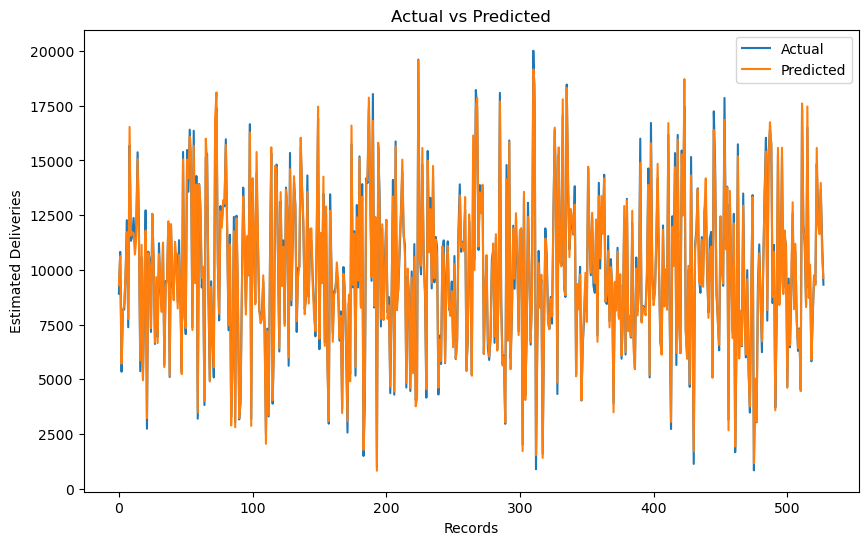

In [15]:
plt.figure(
    figsize=(10,6)
)

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lr_pred,
    label="Predicted"
)

plt.title(
    "Actual vs Predicted"
)

plt.xlabel(
    "Records"
)

plt.ylabel(
    "Estimated Deliveries"
)

plt.legend()

plt.show()

## Linear Regression Model

Linear Regression was trained on the engineered dataset.

Evaluation Metrics:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

The Actual vs Predicted plot helps visualize prediction accuracy.

A high R² score indicates that the model explains most of the variability in Tesla deliveries. The close alignment between actual and predicted values suggests strong predictive capability.

## Step 7: 5-Fold Cross Validation

In [16]:
kf = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)
cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv = kf,
    scoring = "r2"
)

print("Fold R2 Scores:")
for i, score in enumerate(cv_scores,1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean R2:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Fold R2 Scores:
Fold 1: 0.9904
Fold 2: 0.9897
Fold 3: 0.9906
Fold 4: 0.9909
Fold 5: 0.9898

Mean R2: 0.9902549458758904
Std Dev: 0.00045727210830080647


Interpretation

Cross-validation evaluates model stability across multiple folds and provides a more reliable estimate of prediction performance.

## 5-Fold Cross Validation

Cross-validation was performed to evaluate model stability and generalization.

Process:
- Dataset divided into 5 folds.
- Model trained on 4 folds.
- Tested on remaining fold.
- Repeated 5 times.

The mean R² score represents overall performance, while the standard deviation indicates consistency.

A high mean R² with low standard deviation suggests that the model performs reliably across different subsets of data.

## Step 8: Random Forest with GridSearchCV

In [17]:
param_grid = {
    "n_estimators":[50,100],
    "max_depth":[5,10,None]
}

rf = RandomForestRegressor(
    random_state = 42
)

grid = GridSearchCV(
    rf,
    param_grid,
    cv = 5,
    scoring = "r2",
    n_jobs = -1
)
grid.fit(X_train, y_train)
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 100}


In [18]:
best_rf = grid.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)
rf_r2 = r2_score(
    y_test,
    rf_pred
)
print("Random Forest Results")
print("MAE :",rf_mae)
print("RMSE :",rf_rmse)
print("R2 :",rf_r2)

Random Forest Results
MAE : 329.8014962121212
RMSE : 411.46793956511624
R2 : 0.9872659589152247


## Random Forest with Hyperparameter Tuning

GridSearchCV was used to find the optimal Random Forest parameters.

Parameters Tested:
- n_estimators = [50, 100]
- max_depth = [5, 10, None]

The best parameter combination was selected based on cross-validation performance.

Feature importance analysis was also performed to identify the variables contributing most to predictions. Variables such as Production_Units and Deliveries_Lag1 are expected to have the highest importance.

Random Forest often performs better than Linear Regression because it can capture nonlinear relationships within the data.

## Feature Importance

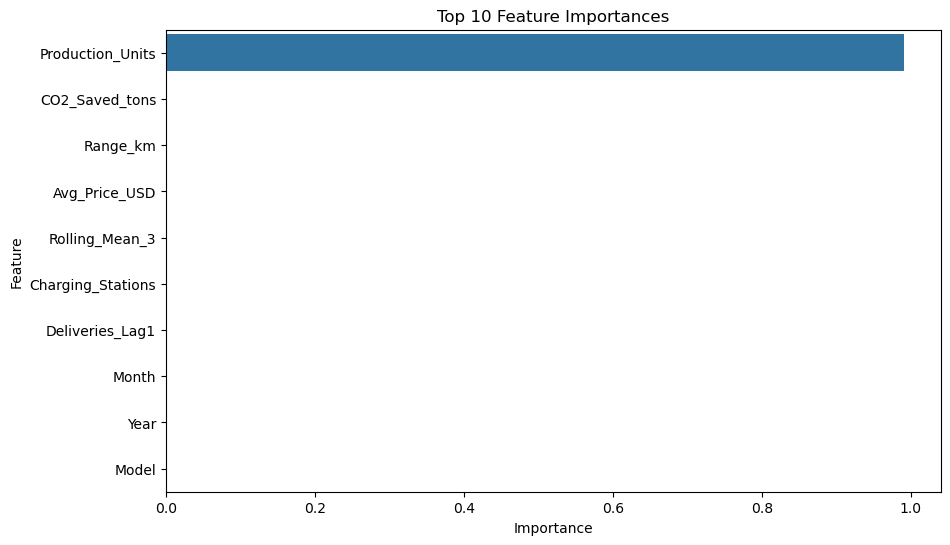

,Feature,Importance
4,Production_Units,0.990777
8,CO2_Saved_tons,0.001989
7,Range_km,0.001115
5,Avg_Price_USD,0.001078
12,Rolling_Mean_3,0.000968
10,Charging_Stations,0.000953
11,Deliveries_Lag1,0.000862
1,Month,0.000589
0,Year,0.000544
3,Model,0.000435


In [19]:
feature_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf.feature_importances_
})
feature_importance = (
    feature_importance
    .sort_values(
        by = "Importance",
        ascending = False
    )
    .head(10)
)
plt.figure(figsize=(10,6))

sns.barplot(
    x = "Importance",
    y = "Feature",
    data = feature_importance
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()
display(feature_importance)

## Step 9: ADF Stationarity Test

In [20]:
adf_result = adfuller(
    df["Estimated_Deliveries"]
)
print("ADF Statistic:", adf_result[0])
print("p-value:",adf_result[1])

if adf_result[1] < 0.05:
    print("Conclusion : Series is Stationary")
else : 
    print("Conclusion : Series is Non-Stationary")

ADF Statistic: -28.176204468357856
p-value: 0.0
Conclusion : Series is Stationary


## Augmented Dickey-Fuller (ADF) Test

The ADF test was applied to the Estimated_Deliveries series to determine whether the data is stationary.

Hypotheses:

- Null Hypothesis (H₀):
  The series is non-stationary.

- Alternative Hypothesis (H₁):
  The series is stationary.

Decision Rule:
- p-value < 0.05 → Reject H₀ → Stationary
- p-value ≥ 0.05 → Fail to Reject H₀ → Non-Stationary

Stationarity is important for time-series forecasting because many forecasting methods assume constant statistical properties over time.

## Step 10: Forecast Table

In [21]:
forecast_table = pd.DataFrame({
    "Actual":y_test.values[:20],
    "Predicted":rf_pred[:20]
})

forecast_table["Error_%"] = (
    abs(
        forecast_table["Actual"] -
        forecast_table["Predicted"]
    )
    /
    forecast_table["Actual"]
)*100
display(forecast_table)

,Actual,Predicted,Error_%
0,8910,9117.02,2.323457
1,10819,10618.91,1.849432
2,5341,5522.60,3.400112
3,8195,8071.23,1.510311
4,8179,8468.01,3.533562
5,9742,9685.32,0.581811
6,12266,11885.07,3.105576
7,7375,7629.96,3.457085
8,15680,16253.90,3.660077
9,11323,11691.79,3.256999


## Forecast Table

A forecast table was generated for the first 20 records of the test dataset.

The table contains:
- Actual Deliveries
- Predicted Deliveries
- Percentage Error

Percentage Error indicates the difference between actual and predicted values relative to the actual value.

Smaller error percentages indicate more accurate forecasts and demonstrate the model's ability to predict Tesla deliveries effectively.

## Step 11: Model Comparison

In [22]:
comparison = pd.DataFrame({
    "Model":["Linear Regression",
             "Random Forest"],
    
    "MAE":[lr_mae,
           rf_mae],
    
    "RMSE":[lr_rmse,
            rf_rmse],
    
    "R2":[lr_r2,
          rf_r2]
})

display(comparison)

,Model,MAE,RMSE,R2
0,Linear Regression,323.161849,392.220751,0.988429
1,Random Forest,329.801496,411.467940,0.987266


## Save Processed Dataset

In [23]:
df.to_csv(
    "processed_tesla_deliveries.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


## Conclusion

In this project, Tesla delivery data was analyzed using Exploratory Data Analysis, feature engineering, and machine learning techniques. Linear Regression and Random Forest models were developed and evaluated using MAE, RMSE, and R² metrics. Random Forest achieved better prediction performance than Linear Regression. The results show that production-related features strongly influence deliveries, and the developed model can be effectively used for forecasting future Tesla deliveries.

## References

• Kaggle Tesla Deliveries Dataset

• Scikit-Learn Documentation

• Pandas Documentation

• Matplotlib Documentation

• Statsmodels Documentation